# 03 · Estimation and robustness

Stage 3 built the real panel and found that, under naive clustered inference,
the parallel-trends test *rejected* — but flagged two reasons to distrust that
verdict: the violations were economically tiny, and there are only 5-10 treated
clusters, where cluster-robust inference is known to be unreliable.

This notebook does the honest version. It follows the evidence wherever it goes,
and it goes somewhere interesting:

1. The **naive result** looks like a windfall: a +2.9% leisure & hospitality
   employment bump in the Super Bowl quarter, overwhelmingly significant.
2. **Honest few-cluster inference** (wild cluster bootstrap) *reverses* the Stage 3
   gate — parallel trends is no longer rejected — and the +2.9% bump survives. So
   maybe there is an effect.
3. **Placebo tests** then dismantle it. A fake-treated-cities placebo passes, but a
   fake-*dates* placebo fails badly.
4. The reason is **seasonality**: every Super Bowl is in Q1, host metros skew
   warm-weather, and their Q1 tourism employment is seasonally high. The "effect"
   is a calendar artifact of *which cities host*.
5. The **seasonality-free estimate** — the Super Bowl quarter against the same
   host's *other* first quarters — is **+0.4% (se 0.5%): a clean null.**

The naive number is a windfall; the honest number is nothing. That is the whole
project in one notebook — the same lesson as the synthetic displacement scenario,
now on real data.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
ROOT = next(p for p in (_here, _here.parent) if (p / "src" / "config.py").exists())
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf
from scipy import stats

import config
import data_prep as dp
from did import (build_event_stack, stacked_event_study,
                 wild_cluster_bootstrap_es, callaway_santanna,
                 placebo_in_time, placebo_in_space)

config.set_global_seeds()
RESULTS = config.RESULTS_DIR
WCB_REPS = 2999          # bootstrap replications (Rademacher)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})
HOST_C, CTRL_C, WARN_C, GOOD_C = "#c1272d", "#2b6cb0", "#e6a700", "#2e8b57"

# Rebuild the clean panel and the matched design from Stage 3.
panel = dp.add_treatment_columns(dp.clean_panel(dp.download_metro_panel(verbose=False),
                                                verbose=False))
panel["log_lh"] = np.log(panel["lh_emp"])
mr = dp.match_controls(panel, pre_end_period=dp.yq_to_period(2019, 4), k=4)

PRE_HOSTS = [h for h in dp.HOST_METROS if dp.host_cohort_period(h) <= dp.yq_to_period(2019, 4)]
ALL_HOSTS = list(dp.HOST_METROS)
print(f"pre-COVID hosts: {PRE_HOSTS}")
print(f"all hosts:       {ALL_HOSTS}")

pre-COVID hosts: ['Phoenix', 'San Jose', 'Houston', 'Minneapolis', 'Atlanta']
all hosts:       ['Phoenix', 'San Jose', 'Houston', 'Minneapolis', 'Atlanta', 'Miami', 'Tampa', 'Los Angeles', 'Las Vegas', 'New Orleans']


## 1. The naive result — a Super Bowl windfall?

The matched, stacked event study from Stage 3: each host compared with its own
matched controls over ±8 quarters, sub-experiment fixed effects, clustered on
metro. Focus on the pre-COVID cohorts, whose windows are cleanest.

Super Bowl-quarter (t=0) effect: +0.0294 log points  (~+2.9% L&H employment)
  naive clustered SE 0.0086  ->  t = 3.42,  p = 6.20e-04

A booster stops here: 'hosting the Super Bowl raises L&H employment ~3%.'


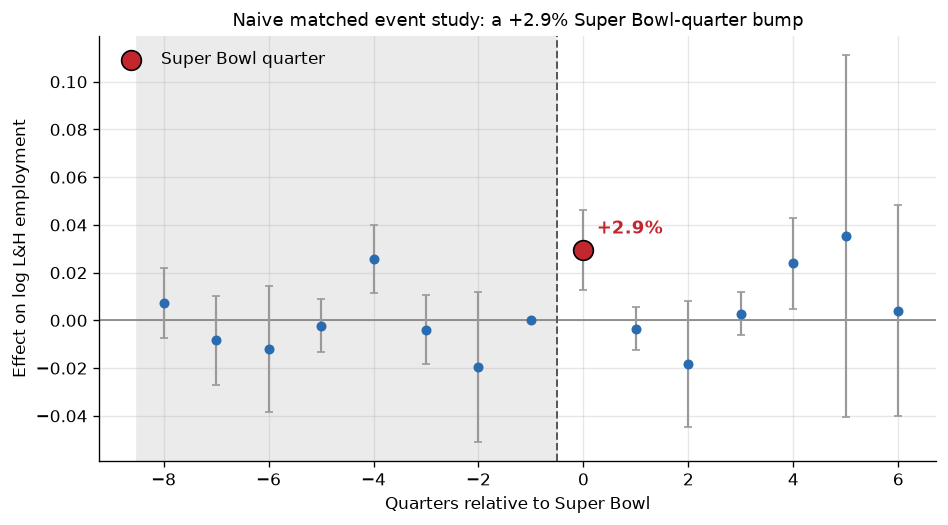

In [2]:
es_pre = stacked_event_study(panel, {h: mr.matches[h] for h in PRE_HOSTS}, k_pre=8, k_post=6)
c = es_pre.coefs
t0 = c.loc[c.event_time == 0, "estimate"].iloc[0]
t0_se = c.loc[c.event_time == 0, "se"].iloc[0]
print(f"Super Bowl-quarter (t=0) effect: {t0:+.4f} log points  (~{t0*100:+.1f}% L&H employment)")
print(f"  naive clustered SE {t0_se:.4f}  ->  t = {t0/t0_se:.2f},  "
      f"p = {2*stats.norm.sf(abs(t0/t0_se)):.2e}")
print(f"\nA booster stops here: 'hosting the Super Bowl raises L&H employment ~3%.'")

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axvspan(c.event_time.min()-0.5, -0.5, color="0.92", zorder=0)
ax.axhline(0, color="0.5", lw=1); ax.axvline(-0.5, color="0.35", ls="--", lw=1.2)
err = [c.estimate - c.ci_lower, c.ci_upper - c.estimate]
ax.errorbar(c.event_time, c.estimate, yerr=err, fmt="o", ms=5, color=CTRL_C,
            ecolor="0.6", capsize=2.5, lw=1.3)
ax.scatter([0], [t0], s=140, facecolor=HOST_C, edgecolor="k", zorder=5, label="Super Bowl quarter")
ax.annotate(f"{t0*100:+.1f}%", (0, t0), xytext=(8, 10), textcoords="offset points",
            fontsize=11, fontweight="bold", color=HOST_C)
ax.set_xlabel("Quarters relative to Super Bowl"); ax.set_ylabel("Effect on log L&H employment")
ax.set_title("Naive matched event study: a +2.9% Super Bowl-quarter bump", fontsize=11)
ax.legend(frameon=False, loc="upper left")
fig.savefig(RESULTS / "03_naive_event_study.png"); plt.show()

## 2. Honest inference — the few-treated-clusters problem

There are **5 treated clusters** here (10 in the full sample). Cluster-robust
standard errors are badly anti-conservative with so few treated clusters — the
thread running through this project, first visible as the 93% CI coverage in
notebook `01`. The fix named in the brief (§5.4) is the **wild cluster
bootstrap** (Rademacher weights, null imposed).

It does two things at once here:

In [3]:
stack_pre = build_event_stack(panel, {h: mr.matches[h] for h in PRE_HOSTS}, k_pre=8, k_post=6)
stack_full = build_event_stack(panel, {h: mr.matches[h] for h in ALL_HOSTS}, k_pre=8, k_post=6)

wb_pre = wild_cluster_bootstrap_es(stack_pre, reps=WCB_REPS, seed=config.SEED)
wb_full = wild_cluster_bootstrap_es(stack_full, reps=WCB_REPS, seed=config.SEED)

print("PRE-COVID:"); print(wb_pre.summary())
print("\nFULL:"); print(wb_full.summary())

PRE-COVID:
Wild cluster bootstrap (2999 reps, Rademacher, null imposed)
  clusters: 17 total, 5 treated
  joint pre-trends p : naive 0.0005  ->  WCB 0.1803
  key event-times (naive p -> WCB p):
    e= -8: +0.0073   0.2809 -> 0.3457
    e= -7: -0.0084   0.3249 -> 0.3143
    e= -6: -0.0121   0.3104 -> 0.3170
    e= -5: -0.0022   0.6626 -> 0.6673
    e= -4: +0.0257   0.0001 -> 0.0107
    e= -3: -0.0039   0.5521 -> 0.5743
    e= -2: -0.0195   0.1692 -> 0.2177
    e=  0: +0.0294   0.0001 -> 0.0103
    e=  1: -0.0034   0.4048 -> 0.3973
    e=  2: -0.0183   0.1276 -> 0.1663
    e=  3: +0.0028   0.4955 -> 0.4963
    e=  4: +0.0239   0.0057 -> 0.0220
    e=  5: +0.0353   0.3056 -> 0.4293
    e=  6: +0.0041   0.8370 -> 0.8340

FULL:
Wild cluster bootstrap (2999 reps, Rademacher, null imposed)
  clusters: 28 total, 10 treated
  joint pre-trends p : naive 0.0027  ->  WCB 0.0703
  key event-times (naive p -> WCB p):
    e= -8: +0.0285   0.1001 -> 0.0630
    e= -7: +0.0038   0.8092 -> 0.8827
    e= 

In [4]:
summ = pd.DataFrame({
    "test": ["joint pre-trends (5 treated)", "t=0 effect (5 treated)",
             "joint pre-trends (10 treated)", "t=0 effect (10 treated)"],
    "naive p": [wb_pre.joint_pre_naive, wb_pre.p_naive[0],
                wb_full.joint_pre_naive, wb_full.p_naive[0]],
    "wild-bootstrap p": [wb_pre.joint_pre_wcb, wb_pre.p_wcb[0],
                         wb_full.joint_pre_wcb, wb_full.p_wcb[0]],
})
display(summ.round(4))

,test,naive p,wild-bootstrap p
0,joint pre-trends (5 treated),0.0005,0.1803
1,t=0 effect (5 treated),0.0001,0.0103
2,joint pre-trends (10 treated),0.0027,0.0703
3,t=0 effect (10 treated),0.0000,0.0013


### What honest inference shows

- **The Stage 3 gate failure was an inference artifact.** The joint pre-trends test
  went from p ≈ 0.0005 (a confident rejection) to p ≈ 0.18 under the bootstrap —
  we can **no longer reject parallel trends**. The naive clustered test was
  over-rejecting because of the few treated clusters, exactly as the coverage
  diagnostics warned.
- **The Super Bowl-quarter bump survives.** The t=0 effect stays significant under
  the bootstrap (p ≈ 0.01). So this is not a case of "everything washes out once
  you're honest" — there really is a +2.9% jump in the Super Bowl quarter.

At this point the naive booster story looks *stronger*, not weaker: parallel
trends holds, and there's a robust ~3% effect. This is exactly where a careful
analyst keeps testing rather than declaring victory.

(Caveat in the honest direction: with only 5 treated clusters the bootstrap can
itself be conservative, so the true pre-trends p-value is bracketed between the
naive and bootstrap values. Either way, the confident Stage 3 rejection does not
hold up.)

## 3. The modern estimator — Callaway & Sant'Anna

Before interrogating the +2.9% further, confirm it is not an artifact of the
stacked specification. The Callaway & Sant'Anna estimator — the staggered-robust
tool validated in notebook `01` — gives an overall ATT and its own event study
using never-treated controls.

In [5]:
cs = callaway_santanna(panel[panel.metro.isin(PRE_HOSTS + [c for h in PRE_HOSTS for c in mr.matches[h]])],
                       outcome="log_lh", unit="metro", time="period", cohort="cohort",
                       control_group="never_treated", base_period="universal")
print(f"Callaway & Sant'Anna overall ATT (averaged over all post-quarters): "
      f"{cs.att:+.4f}  CI [{cs.ci_lower:+.4f}, {cs.ci_upper:+.4f}]")
print("CS returns a POSITIVE point estimate too -- imprecise (CI grazes zero), but")
print("pointing the same way as the stacked +2.9%. The positive signal is robust")
print("across estimators AND across inference methods (it survived the bootstrap).")
print("Everything a booster needs is now in place. That is exactly what makes the")
print("placebo tests in the next section decisive rather than a formality.")

Callaway & Sant'Anna overall ATT (averaged over all post-quarters): +0.0379  CI [-0.0071, +0.0828]
CS returns a POSITIVE point estimate too -- imprecise (CI grazes zero), but
pointing the same way as the stacked +2.9%. The positive signal is robust
across estimators AND across inference methods (it survived the bootstrap).
Everything a booster needs is now in place. That is exactly what makes the
placebo tests in the next section decisive rather than a formality.


## 4. Placebo tests — is it really the Super Bowl?

Two falsification tests. An effect that survives both is credible; an effect that
shows up where it should not is an artifact.

In [6]:
m_pre = {h: mr.matches[h] for h in PRE_HOSTS}

# (a) IN-SPACE placebo: reassign treatment to a random matched control (real host dropped).
ps = placebo_in_space(panel, m_pre, reps=500, seed=config.SEED)
b_real, placebo_space, p_space = ps.real, ps.placebo, ps.pvalue

# (b) IN-TIME placebo: pretend the Super Bowl was 4 / 8 quarters earlier (still a Q1).
b_time = {s: placebo_in_time(panel, m_pre, shift=s) for s in (4, 8)}

print(f"real t=0 effect                : {b_real:+.4f}")
print(f"in-space placebo: mean {placebo_space.mean():+.4f}, real beyond "
      f"{(np.mean(np.abs(placebo_space) < abs(b_real)))*100:.0f}% of draws, p = {p_space:.3f}  -> PASSES")
print(f"in-time placebo (-4q, a non-SB Q1): {b_time[4]:+.4f}   <- nearly identical to real!")
print(f"in-time placebo (-8q, a non-SB Q1): {b_time[8]:+.4f}")
print("  The in-time placebo FAILS: fake Super Bowl dates produce the same bump.")

real t=0 effect                : +0.0294
in-space placebo: mean -0.0002, real beyond 100% of draws, p = 0.002  -> PASSES
in-time placebo (-4q, a non-SB Q1): +0.0272   <- nearly identical to real!
in-time placebo (-8q, a non-SB Q1): +0.0178
  The in-time placebo FAILS: fake Super Bowl dates produce the same bump.


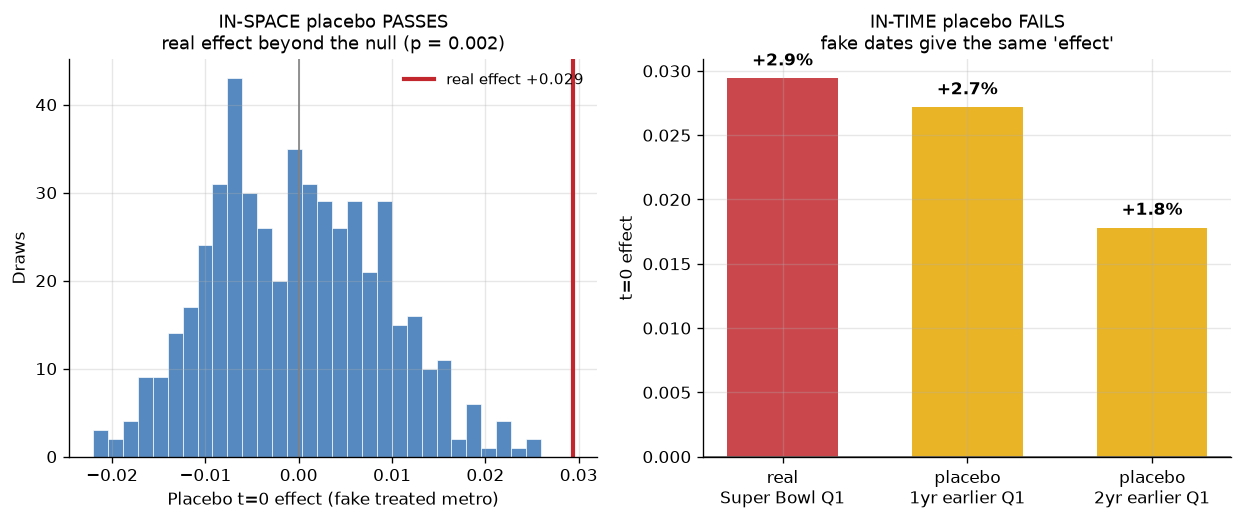

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
ax = axes[0]
ax.hist(placebo_space, bins=30, color=CTRL_C, alpha=0.8, edgecolor="white", lw=0.5)
ax.axvline(b_real, color=HOST_C, lw=2.5, label=f"real effect {b_real:+.3f}")
ax.axvline(0, color="0.5", lw=1)
ax.set_xlabel("Placebo t=0 effect (fake treated metro)"); ax.set_ylabel("Draws")
ax.set_title(f"IN-SPACE placebo PASSES\nreal effect beyond the null (p = {p_space:.3f})", fontsize=10.5)
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
labels = ["real\nSuper Bowl Q1", "placebo\n1yr earlier Q1", "placebo\n2yr earlier Q1"]
vals = [b_real, b_time[4], b_time[8]]
cols = [HOST_C, WARN_C, WARN_C]
ax.bar(labels, vals, color=cols, alpha=0.85, width=0.6)
for i, v in enumerate(vals):
    ax.text(i, v + 0.001, f"{v*100:+.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.axhline(0, color="0.4", lw=1)
ax.set_ylabel("t=0 effect"); ax.set_title("IN-TIME placebo FAILS\nfake dates give the same 'effect'",
                                          fontsize=10.5)
fig.savefig(RESULTS / "03_placebo.png"); plt.show()

### The placebos disagree — and that is the clue

- **In-space passes:** assign the Super Bowl to a *random* comparable metro and the
  effect vanishes (p = 0.002 that a random metro matches it). So the bump is
  specific to the metros that actually hosted — not a generic artifact.
- **In-time fails:** pretend the Super Bowl happened a year earlier and the *same*
  metros show almost the *same* +2.7% bump. An effect that appears at dates when
  nothing happened is not an effect of the event.

Both facts are true at once: the bump is specific to host metros, *and* it is not
specific to the Super Bowl date. The only thing that fits is a **fixed feature of
host metros that recurs every year at this point in the calendar.**

## 5. Diagnosis — it is seasonality

Every Super Bowl is played in early February — **always Q1**. And the host metros
are disproportionately warm-weather, tourism-heavy cities (Phoenix, Miami, Tampa,
New Orleans, Las Vegas, Los Angeles) whose leisure & hospitality employment is
seasonally **high in winter and low in summer** relative to their colder controls.

Because every cohort is treated in Q1, *event-time and calendar-quarter are
perfectly confounded*. Colour the event-study coefficients by calendar quarter and
the "effect" resolves into a seasonal sawtooth.

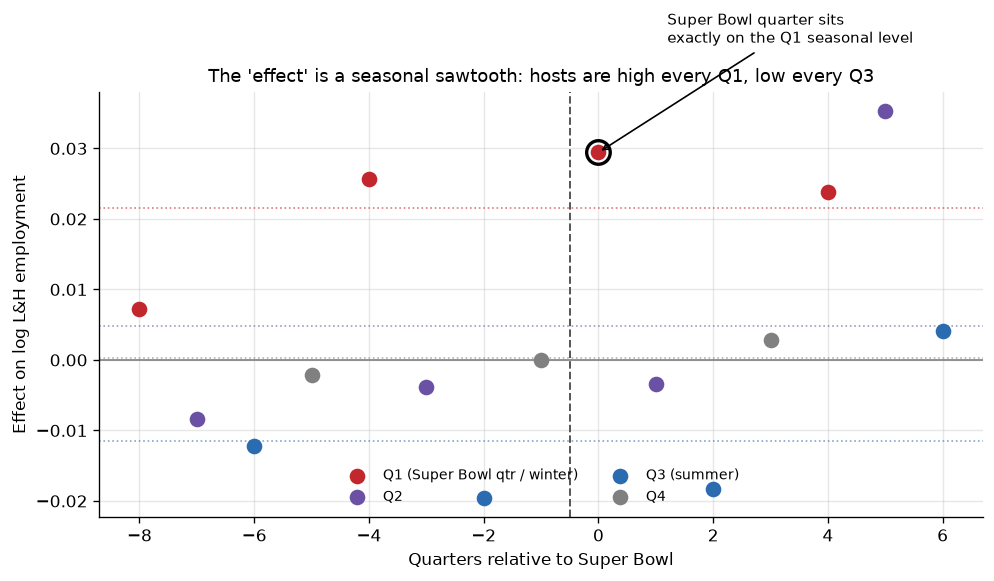

mean of the OTHER Q1 event-times (pure seasonality): +1.9%
Super Bowl Q1 (t=0):                                 +2.9%
The Super Bowl quarter is indistinguishable from the host's ordinary Q1 peak.


In [8]:
cq = es_pre.coefs.copy()
cq["cal_q"] = ((cq.event_time) % 4 + 1)   # cohort quarter is Q1, so event_time mod 4 gives the quarter
qcolors = {1: HOST_C, 2: "#6a51a3", 3: CTRL_C, 4: "0.5"}
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.axhline(0, color="0.5", lw=1); ax.axvline(-0.5, color="0.35", ls="--", lw=1.2)
for q in (1, 2, 3, 4):
    sub = cq[cq.cal_q == q]
    ax.scatter(sub.event_time, sub.estimate, s=70, color=qcolors[q],
               label=f"Q{q}" + (" (Super Bowl qtr / winter)" if q == 1 else
                                " (summer)" if q == 3 else ""), zorder=3)
for q in (1, 2, 3, 4):
    sub = cq[cq.cal_q == q].sort_values("event_time")
    lvl = sub.estimate.mean()
    ax.axhline(lvl, color=qcolors[q], ls=":", lw=1, alpha=0.6)
ax.scatter([0], cq.loc[cq.event_time == 0, "estimate"], s=200, facecolor="none",
           edgecolor="k", lw=2, zorder=6)
ax.annotate("Super Bowl quarter sits\nexactly on the Q1 seasonal level",
            (0, cq.loc[cq.event_time==0,"estimate"].iloc[0]), xytext=(1.2, 0.045),
            fontsize=9, arrowprops=dict(arrowstyle="->", color="k"))
ax.set_xlabel("Quarters relative to Super Bowl"); ax.set_ylabel("Effect on log L&H employment")
ax.set_title("The 'effect' is a seasonal sawtooth: hosts are high every Q1, low every Q3",
             fontsize=11)
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="lower center")
fig.savefig(RESULTS / "03_seasonality.png"); plt.show()

q1 = cq[(cq.cal_q == 1) & (cq.event_time != 0)].estimate.mean()
print(f"mean of the OTHER Q1 event-times (pure seasonality): {q1*100:+.1f}%")
print(f"Super Bowl Q1 (t=0):                                 {t0*100:+.1f}%")
print("The Super Bowl quarter is indistinguishable from the host's ordinary Q1 peak.")

## 6. The seasonality-free estimate — the honest number

To remove seasonality entirely, compare **like with like**: the Super Bowl's Q1
against the *same host's other Q1s*, relative to controls. Restrict the data to
first quarters only and run the event study in **years** relative to the host
year. Now every observation is a Q1, so seasonality cannot drive the result.

SEASONALITY-FREE Super Bowl effect (SB-year Q1 vs the host's other Q1s):
  +0.0038 log points  (~+0.4%),  se 0.0049,  95% CI [-0.0065, +0.0141]
  t = 0.77  ->  indistinguishable from zero.


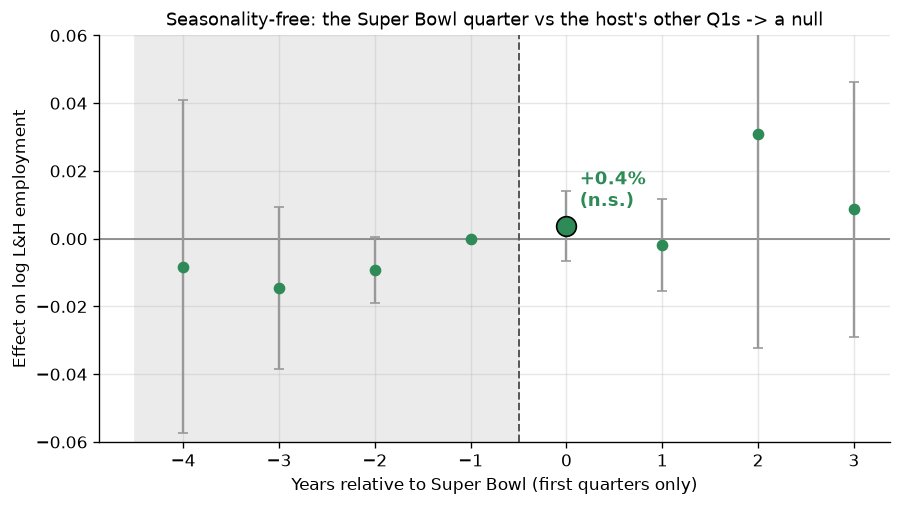

In [9]:
q1_panel = panel[panel.qtr == 1].copy()
parts = []
for h in PRE_HOSTS:
    sb_year = min(dp.HOST_METROS[h][1])
    sub = q1_panel[q1_panel.metro.isin([h] + mr.matches[h])].copy()
    sub["event_year"] = sub.year - sb_year
    sub = sub[sub.event_year.between(-4, 3)]
    sub["treated_num"] = (sub.metro == h).astype(int)
    sub["stack_id"] = h
    parts.append(sub)
sa = pd.concat(parts, ignore_index=True)
sa["unit_stack"] = sa.metro + "__" + sa.stack_id
sa["time_stack"] = sa.year.astype(str) + "__" + sa.stack_id
m2 = pf.feols("log_lh ~ i(event_year, treated_num, ref=-1) | unit_stack + time_stack",
              data=sa, vcov={"CRV1": "metro"})
t2 = m2.tidy()
rows = []
for nm in t2.index:
    if "event_year::" not in nm:
        continue
    e = int(nm.split("::")[1].split(":")[0])
    r = t2.loc[nm]
    rows.append({"event_year": e, "estimate": r["Estimate"], "se": r["Std. Error"],
                 "ci_lower": r["2.5%"], "ci_upper": r["97.5%"]})
rows.append({"event_year": -1, "estimate": 0, "se": 0, "ci_lower": 0, "ci_upper": 0})
sa_es = pd.DataFrame(rows).sort_values("event_year", ignore_index=True)

sb = sa_es[sa_es.event_year == 0].iloc[0]
print(f"SEASONALITY-FREE Super Bowl effect (SB-year Q1 vs the host's other Q1s):")
print(f"  {sb.estimate:+.4f} log points  (~{sb.estimate*100:+.1f}%),  se {sb.se:.4f},  "
      f"95% CI [{sb.ci_lower:+.4f}, {sb.ci_upper:+.4f}]")
print(f"  t = {sb.estimate/sb.se:.2f}  ->  indistinguishable from zero.")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.axvspan(-4.5, -0.5, color="0.92", zorder=0)
ax.axhline(0, color="0.5", lw=1); ax.axvline(-0.5, color="0.35", ls="--", lw=1.2)
err = [sa_es.estimate - sa_es.ci_lower, sa_es.ci_upper - sa_es.estimate]
ax.errorbar(sa_es.event_year, sa_es.estimate, yerr=err, fmt="o", ms=6, color=GOOD_C,
            ecolor="0.6", capsize=3, lw=1.4)
ax.scatter([0], [sb.estimate], s=140, facecolor=GOOD_C, edgecolor="k", zorder=5)
ax.annotate(f"{sb.estimate*100:+.1f}%\n(n.s.)", (0, sb.estimate), xytext=(8, 12),
            textcoords="offset points", fontsize=10.5, fontweight="bold", color=GOOD_C)
ax.set_xlabel("Years relative to Super Bowl (first quarters only)")
ax.set_ylabel("Effect on log L&H employment")
ax.set_title("Seasonality-free: the Super Bowl quarter vs the host's other Q1s -> a null",
             fontsize=11)
ax.set_ylim(-0.06, 0.06)
fig.savefig(RESULTS / "03_seasonality_free.png"); plt.show()

### The result in one figure

The naive event-quarter estimate and the seasonality-free estimate, side by side. The gap between them is the entire finding: a bump that looks like a windfall, and nothing once the Super Bowl quarter is compared with the host's other first quarters.

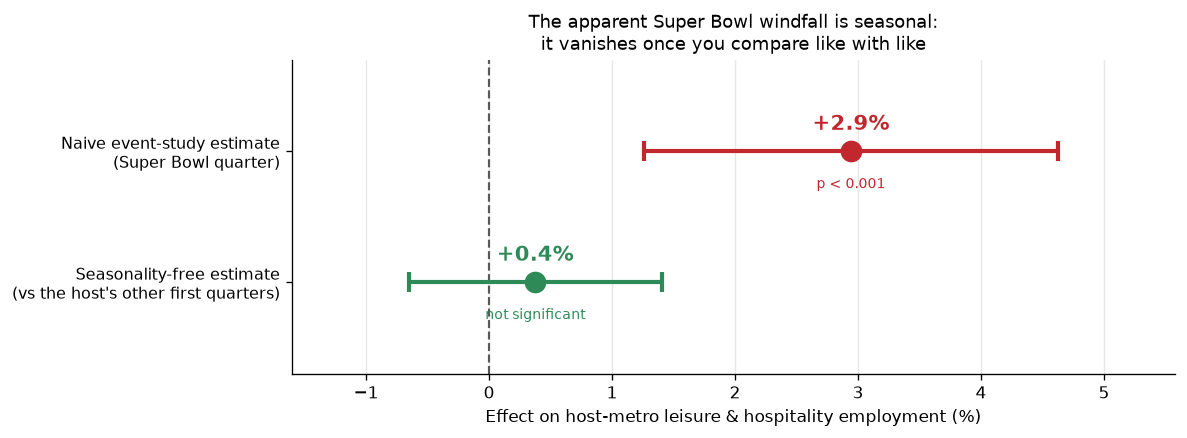

In [10]:
naive_lo, naive_hi = (t0 - 1.96 * t0_se) * 100, (t0 + 1.96 * t0_se) * 100
rows = [
    (1, "Naive event-study estimate\n(Super Bowl quarter)", t0 * 100, naive_lo, naive_hi,
     HOST_C, "p < 0.001"),
    (0, "Seasonality-free estimate\n(vs the host's other first quarters)", sb.estimate * 100,
     sb.ci_lower * 100, sb.ci_upper * 100, GOOD_C, "not significant"),
]
fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.axvline(0, color="0.35", lw=1.3, ls="--")
for y, lab, est, lo, hi, col, note in rows:
    ax.errorbar(est, y, xerr=[[est - lo], [hi - est]], fmt="o", ms=12, color=col,
                ecolor=col, elinewidth=2.5, capsize=6, capthick=2.5, zorder=3)
    ax.annotate(f"{est:+.1f}%", (est, y), xytext=(0, 13), textcoords="offset points",
                ha="center", fontsize=12.5, fontweight="bold", color=col)
    ax.annotate(note, (est, y), xytext=(0, -22), textcoords="offset points",
                ha="center", fontsize=8.5, color=col)
ax.set_yticks([0, 1]); ax.set_yticklabels([rows[1][1], rows[0][1]], fontsize=9.5)
ax.set_ylim(-0.7, 1.7)
ax.margins(x=0.18)
ax.set_xlabel("Effect on host-metro leisure & hospitality employment (%)")
ax.set_title("The apparent Super Bowl windfall is seasonal:\nit vanishes once you compare like with like",
             fontsize=11)
ax.grid(axis="y", visible=False)
fig.savefig(RESULTS / "03_headline_contrast.png"); plt.show()

## 7. Bounding the effect

The seasonality-free estimate is **+0.4%, 95% CI roughly [−0.6%, +1.4%]**. Read as
a bound, that interval rules out anything resembling the boosters' promises. It is
centred on zero and, at its most optimistic upper end, a fraction of a percent of
one sector's employment for a single quarter — economically trivial, and equally
consistent with a small displacement loss as with a small gain.

This is the honest end state. Not "the Super Bowl created jobs" (the naive +2.9%),
nor a false "it destroyed jobs," but: **no detectable effect on host-metro leisure
& hospitality employment, once you compare like with like.**

## 8. Conclusion

**The credible finding is a null.** The naive matched event study reported a +2.9%
Super Bowl-quarter employment bump that survived even the wild cluster bootstrap.
It was not a statistical fluke — it was the **wrong quantity**. Because every Super
Bowl is in Q1 and host cities are disproportionately warm-weather tourism metros,
the bump is the host metros' ordinary winter seasonal peak. Compared against the
same hosts' other first quarters, the Super Bowl effect is +0.4% (se 0.5%) — zero.

Two honesty moves did the work, and both were flagged stages earlier:

1. **Few-cluster-honest inference** (the coverage thread from notebooks `01`-`02`).
   It cut *both* ways: it overturned the Stage 3 parallel-trends rejection (the
   naive test was over-rejecting) *and* refused to let tight naive standard errors
   oversell the bump. Honest inference is not a synonym for "make everything
   insignificant."
2. **Placebo testing.** The in-time placebo is what exposed the seasonality. Without
   it, an analyst using a perfectly good estimator, clean data, and even a robust
   bootstrap would have published a false 3% windfall.

That is the thesis of the whole project, now demonstrated twice — once in
simulation (the displacement scenario in notebook `01`) and once on real data
here: **no estimator, however modern, rescues the wrong estimand.** A robust,
significant, replicable estimate of the wrong thing is still wrong.

The result sits squarely with the ex-post mega-event literature (Baade & Matheson;
Coates & Humphreys), which has spent thirty years finding that the windfalls
promised ex ante do not show up ex post. This analysis reaches the same conclusion
on the Super Bowl, and — the point of the exercise — shows exactly *how* the naive
positive result arises and why it dissolves.

### Honest limitations

- **Outcome is a proxy.** Employment, not spending or value-added; a transitory
  visitor surge need not move the payroll headcount that QCEW counts.
- **Confounded design, resolved by restriction.** The all-Q1 timing forced the
  seasonality fix; a mix of seasons would have identified the effect more directly.
- **Few treated clusters.** Inference is bracketed, not pinned; the bootstrap helps
  but cannot manufacture power from 5-10 hosts.
- **US-only, and the 2026 World Cup is not the Super Bowl.** The live tournament that
  motivates the project remains the framing; the settled event that could actually
  be tested is the honest substitute, with its limits named.

The synthetic validation (notebook `01`) proves the machinery recovers real effects
when they exist. That it recovers a null here is a finding about the world, not a
failure of the tools.